# Used Car Price — Exploratory Data Analysis & Feature Engineering

## Problem Statement

Used-car resale prices can be influenced by several characteristics such as vehicle age, kilometers driven, engine capacity, and number of previous owners.

The objective of this analysis is to explore these characteristics, identify data-quality issues, understand their relationships with resale price, and prepare a clean dataset with meaningful engineered features for further machine learning analysis.

import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
sns.set_style("whitegrid")

loading the dataset

In [3]:
df = pd.read_csv("D:/learn_depth ml/09_used_car_price.csv")

In [4]:
df.head()

,car_age_years,km_driven,engine_cc,owners,price_lakh
0,10.0,109043.0,1183.0,2.0,4.0
1,14.0,157310.0,1292.0,1.0,2.5
2,11.0,66320.0,2915.0,1.0,9.1
3,3.0,197812.0,2773.0,2.0,6.8
4,8.0,135369.0,1458.0,2.0,7.9


understanding the shape,columns,data types and the basic statistics

In [5]:
df.shape

(1020, 5)

In [6]:
df.columns

Index(['car_age_years', 'km_driven', 'engine_cc', 'owners', 'price_lakh'], dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   car_age_years  1010 non-null   float64
 1   km_driven      1009 non-null   float64
 2   engine_cc      1010 non-null   float64
 3   owners         1010 non-null   float64
 4   price_lakh     1020 non-null   float64
dtypes: float64(5)
memory usage: 40.0 KB


In [8]:
df.describe()

,car_age_years,km_driven,engine_cc,owners,price_lakh
count,1010.000000,1009.000000,1010.000000,1010.000000,1020.000000
mean,7.551485,103868.322101,1911.020792,2.058416,6.552647
std,4.613487,56368.430427,634.674019,0.929397,3.350743
min,-2.000000,-10000.000000,803.000000,1.000000,-1.400000
25%,3.000000,57857.000000,1361.000000,1.000000,4.100000
50%,8.000000,102651.000000,1942.000000,2.000000,6.500000
75%,11.000000,154006.000000,2451.250000,3.000000,8.900000
max,15.000000,199977.000000,3000.000000,8.000000,16.400000


In [9]:
df.isnull().sum()

car_age_years    10
km_driven        11
engine_cc        10
owners           10
price_lakh        0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(20)

In [12]:
df[df.duplicated()]

,car_age_years,km_driven,engine_cc,owners,price_lakh
212,14.0,157310.0,1292.0,1.0,2.5
430,3.0,40587.0,949.0,1.0,10.7
553,13.0,106446.0,1846.0,3.0,3.6
583,3.0,134563.0,1454.0,2.0,8.9
584,2.0,53247.0,1671.0,3.0,10.1
587,2.0,107847.0,2240.0,2.0,9.6
604,14.0,82332.0,1022.0,2.0,2.0
620,12.0,178109.0,1517.0,1.0,0.3
634,9.0,48545.0,1049.0,1.0,8.6
653,4.0,102651.0,1714.0,3.0,8.3


### Initial Dataset Observations

- The dataset contains 1,020 rows and 5 numerical columns.
- All variables are currently stored as float64 data types.
- Missing values are present in car_age_years, km_driven, engine_cc, and owners, while price_lakh has no missing values.
- A total of 41 missing values are present in the dataset.
- Duplicate rows are present, with 20 duplicate records identified.
- The descriptive statistics indicate invalid negative values in car_age_years, km_driven, and price_lakh.
- The owners variable has a maximum value of 8, which requires further investigation for unrealistic ownership counts.
- The maximum price of 16.4 lakh will be investigated further for potential outliers.

1. Find negative car age

In [13]:
df[df["car_age_years"] < 0]

,car_age_years,km_driven,engine_cc,owners,price_lakh
192,-2.0,136505.0,1741.0,3.0,-0.0
244,-2.0,19630.0,1218.0,1.0,9.3
261,-2.0,186778.0,2812.0,1.0,3.9
451,-2.0,199977.0,891.0,2.0,3.7
801,-2.0,NaN,1192.0,3.0,7.2


In [14]:
(df["car_age_years"] < 0).sum()

np.int64(5)

2. Find negative kilometers driven

In [15]:
df[df["km_driven"] < 0]

,car_age_years,km_driven,engine_cc,owners,price_lakh
183,8.0,-10000.0,2757.0,1.0,8.5
428,11.0,-10000.0,1821.0,3.0,1.1
904,7.0,-10000.0,1265.0,1.0,7.8
934,2.0,-10000.0,1157.0,2.0,10.6
938,14.0,-10000.0,2104.0,3.0,6.9


In [16]:
(df["km_driven"] < 0).sum()

np.int64(5)

3. Find unrealistic owner counts

In [17]:
df["owners"].value_counts().sort_index()

owners
1.0    333
2.0    310
3.0    362
8.0      5
Name: count, dtype: int64

In [18]:
df[df["owners"] > 3]

,car_age_years,km_driven,engine_cc,owners,price_lakh
515,14.0,179476.0,2755.0,8.0,1.8
613,1.0,149506.0,2324.0,8.0,8.6
874,3.0,185009.0,2023.0,8.0,3.9
915,13.0,168114.0,1926.0,8.0,0.8
964,7.0,123621.0,1792.0,8.0,7.5


In [19]:
(df["owners"] > 3).sum()

np.int64(5)

when the dataset was investigated the statistics showed price_lakh minimum = -1.4 . a car can't have a negative price hence looking on it also 

In [20]:
df[df["price_lakh"]<0]

,car_age_years,km_driven,engine_cc,owners,price_lakh
6,15.0,188248.0,1145.0,3.0,-0.3
45,12.0,177341.0,1195.0,1.0,-0.3
56,13.0,198246.0,1489.0,2.0,-0.7
147,13.0,184454.0,856.0,1.0,-1.0
224,15.0,117084.0,1178.0,3.0,-0.4
264,15.0,119033.0,1598.0,2.0,-0.3
277,15.0,187576.0,1269.0,3.0,-0.8
349,10.0,179713.0,2369.0,1.0,-0.1
361,12.0,183836.0,843.0,2.0,-0.3
364,11.0,189477.0,1315.0,2.0,-0.4


In [21]:
(df["price_lakh"] < 0).sum()

np.int64(18)

Identify price outliers.

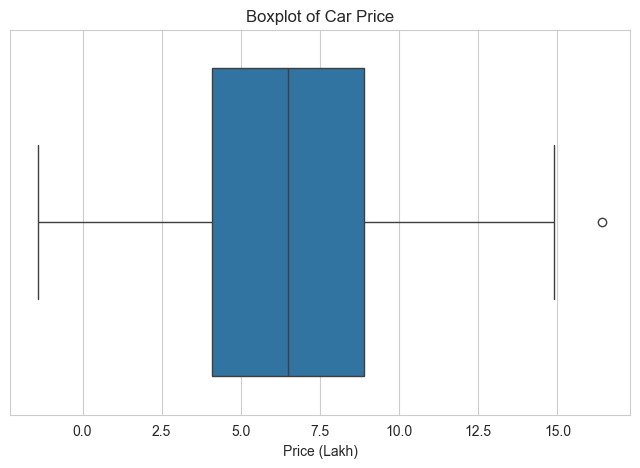

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["price_lakh"])
plt.title("Boxplot of Car Price")
plt.xlabel("Price (Lakh)")
plt.show()

calculating the IQR

In [23]:
price_valid = df[df["price_lakh"] > 0]["price_lakh"]

Q1 = price_valid.quantile(0.25)
Q3 = price_valid.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 4.2
Q3: 9.0
IQR: 4.8
Lower Bound: -2.999999999999999
Upper Bound: 16.2


Find the actual price outliers

In [24]:
price_outliers = df[
    (df["price_lakh"] > upper_bound)
]

price_outliers

,car_age_years,km_driven,engine_cc,owners,price_lakh
367,1.0,25497.0,2677.0,1.0,16.4


In [25]:
len(price_outliers)

1

In [26]:
price_outliers["price_lakh"].sort_values()

367    16.4
Name: price_lakh, dtype: float64

Plot car-age distribution

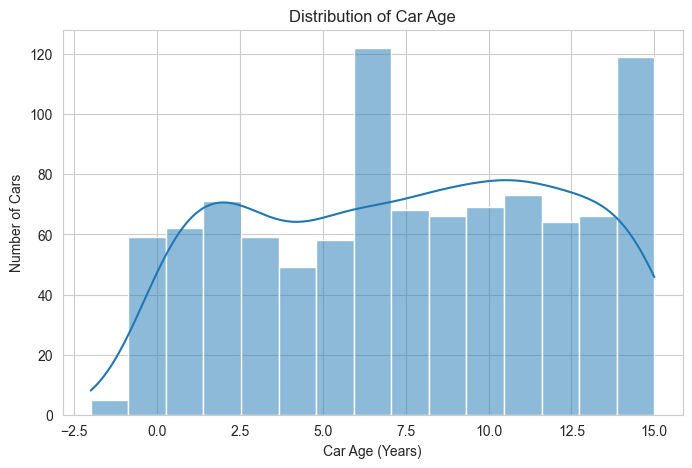

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(df["car_age_years"], bins=15, kde=True)
plt.title("Distribution of Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Number of Cars")
plt.show()

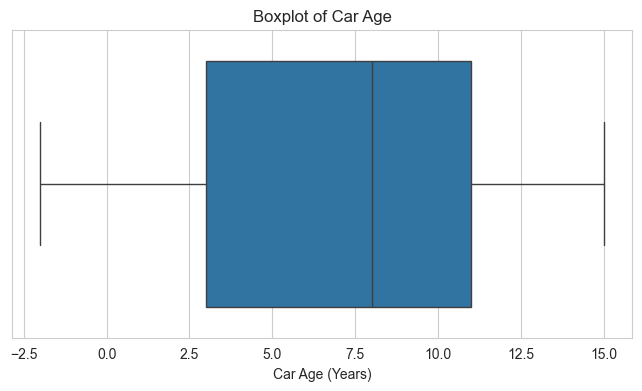

In [28]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["car_age_years"])

plt.title("Boxplot of Car Age")
plt.xlabel("Car Age (Years)")
plt.show()

Plot car age and kilometer distributions.

## Distribution of Car Age

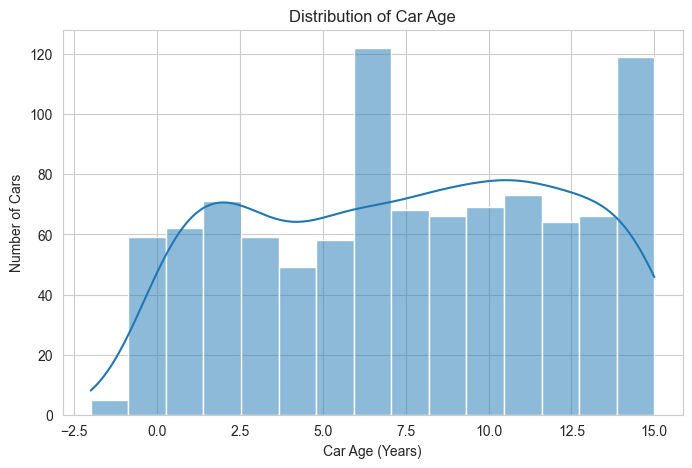

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="car_age_years", bins=15, kde=True)

plt.title("Distribution of Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Number of Cars")

plt.show()

## Distribution of Kilometers Driven

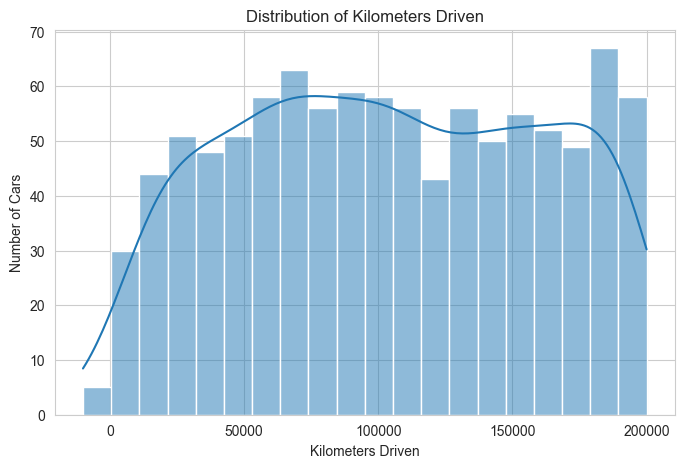

In [30]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="km_driven", bins=20, kde=True)

plt.title("Distribution of Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Number of Cars")

plt.show()

box plots

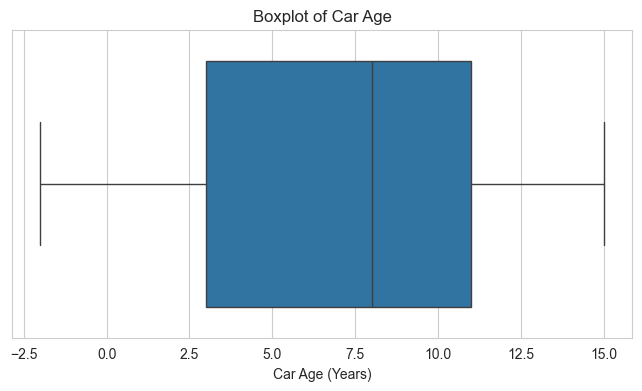

In [31]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["car_age_years"])

plt.title("Boxplot of Car Age")
plt.xlabel("Car Age (Years)")

plt.show()

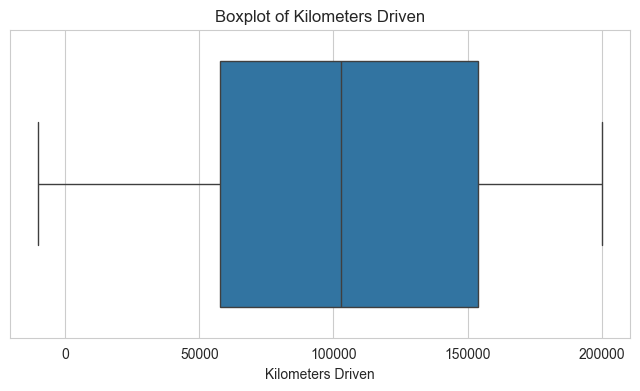

In [32]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["km_driven"])

plt.title("Boxplot of Kilometers Driven")
plt.xlabel("Kilometers Driven")

plt.show()

	Analyze car age vs price, kilometers vs price, and engine size vs price.

## Car Age vs Price

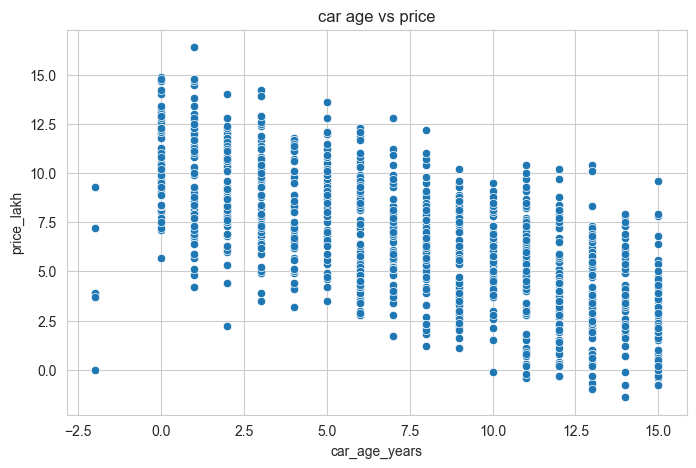

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="car_age_years",y="price_lakh")
plt.title("car age vs price")
plt.xlabel("car_age_years")
plt.ylabel("price_lakh")
plt.show()

* The scatter plot shows a negative relationship
* Younger cars generally have higher prices.
* As car_age_years increases, the price tends to decrease.
* There is still considerable variation in price at each age, so age is not the only factor affecting price.
* The negative car_age_years values are visible on the left and will be handled during cleaning.

## Kilometers Driven vs Price

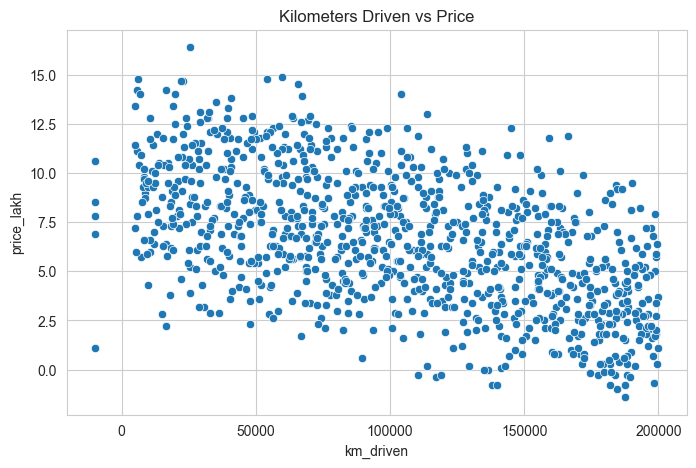

In [35]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="km_driven", y="price_lakh")
plt.title("Kilometers Driven vs Price")
plt.xlabel("km_driven")
plt.ylabel("price_lakh")
plt.show()


* plot shows a negative relationship 
* Cars with lower mileage tend to have higher prices.
* As km_driven increases, prices generally decrease.
* The relationship is somewhat scattered, meaning mileage alone doesn't determine price.
* The negative -10000 values are invalid and are visible near the left side.


## Engine Size vs Price

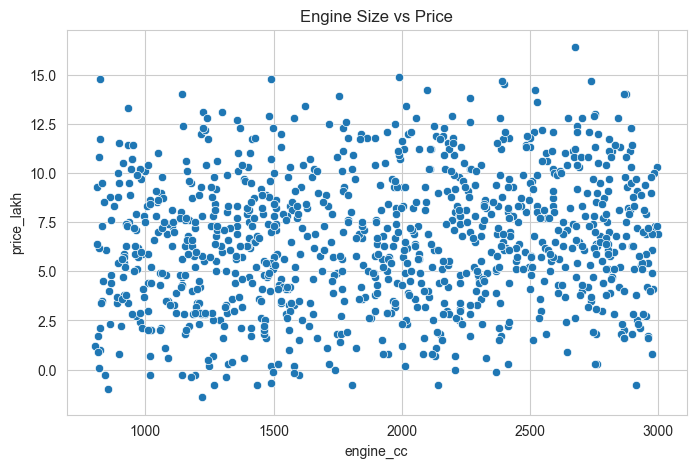

In [36]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="engine_cc", y="price_lakh")
plt.title("Engine Size vs Price")
plt.xlabel("engine_cc")
plt.ylabel("price_lakh")
plt.show()

# correation heatmap 

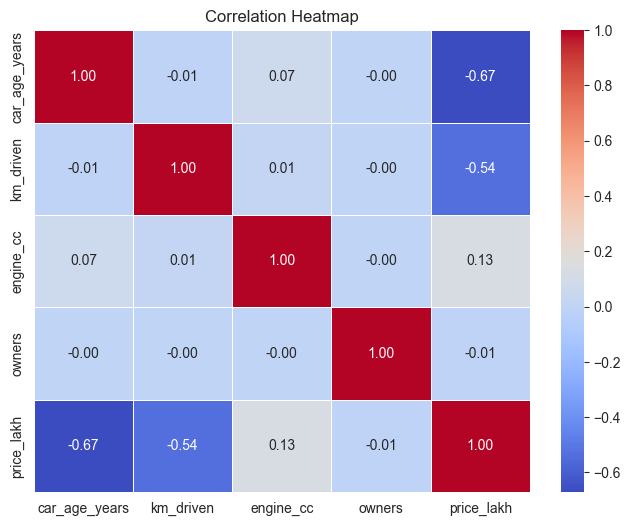

In [37]:
plt.figure(figsize=(8,6))
correlation_matrix = df.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

	Clean duplicates, missing values, and invalid values.

In [38]:
df_clean=df.copy()

remove duplicate rows

In [40]:
df_clean = df_clean.drop_duplicates()

print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (1000, 5)


Convert invalid feature values to missing

In [41]:
df_clean.loc[df_clean["car_age_years"] < 0, "car_age_years"] = np.nan

In [42]:
df_clean.loc[df_clean["km_driven"] < 0, "km_driven"] = np.nan

Unrealistic owners: there is  8 is the unrealistic value in this dataset.

In [43]:
df_clean.loc[df_clean["owners"] > 3, "owners"] = np.nan

In [44]:
df_clean.loc[df_clean["price_lakh"] < 0, "price_lakh"] = np.nan

Check missing values again

In [45]:
df_clean.isnull().sum()

car_age_years    15
km_driven        15
engine_cc        10
owners           15
price_lakh       18
dtype: int64

Handle missing feature values

In [46]:
feature_columns = ["car_age_years", "km_driven", "engine_cc", "owners"]

for column in feature_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

Handle invalid/missing target values

In [47]:
df_clean = df_clean.dropna(subset=["price_lakh"])

In [48]:
df_clean.isnull().sum()

car_age_years    0
km_driven        0
engine_cc        0
owners           0
price_lakh       0
dtype: int64

Check the cleaned dataset

In [49]:
df_clean.shape

(982, 5)

In [50]:
df_clean.describe()

,car_age_years,km_driven,engine_cc,owners,price_lakh
count,982.000000,982.000000,982.000000,982.000000,982.000000
mean,7.495927,103097.044807,1921.560081,2.035642,6.688086
std,4.508174,55471.585857,632.282896,0.823800,3.240520
min,0.000000,5025.000000,803.000000,1.000000,-0.000000
25%,4.000000,58083.250000,1376.250000,1.000000,4.200000
50%,8.000000,101859.000000,1945.500000,2.000000,6.600000
75%,11.000000,150695.000000,2461.750000,3.000000,9.000000
max,15.000000,199977.000000,3000.000000,3.000000,16.400000


In [51]:
df_clean.head()

,car_age_years,km_driven,engine_cc,owners,price_lakh
0,10.0,109043.0,1183.0,2.0,4.0
1,14.0,157310.0,1292.0,1.0,2.5
2,11.0,66320.0,2915.0,1.0,9.1
3,3.0,197812.0,2773.0,2.0,6.8
4,8.0,135369.0,1458.0,2.0,7.9


Verify that invalid values are gone

In [52]:
(df_clean["car_age_years"] < 0).sum()

np.int64(0)

In [53]:
(df_clean["km_driven"] < 0).sum()

np.int64(0)

In [54]:
(df_clean["owners"] > 3).sum()

np.int64(0)

In [56]:
(df_clean["price_lakh"] < 0).sum()

np.int64(0)

In [57]:
df_clean.duplicated().sum()

np.int64(0)

In [88]:
print("Final Shape:", df_clean.shape)

print("\nMissing Values:")
print(df_clean.isnull().sum())

print("\nDuplicate Rows:", df_clean.duplicated().sum())

print("\nNegative Car Age:", (df_clean["car_age_years"] < 0).sum())

print("Negative Kilometers:", (df_clean["km_driven"] < 0).sum())

print("Unrealistic Owners:", (df_clean["owners"] > 3).sum())

print("Negative Prices:", (df_clean["price_lakh"] < 0).sum())

Final Shape: (982, 7)

Missing Values:
car_age_years    0
km_driven        0
engine_cc        0
owners           0
price_lakh       0
km_per_year      0
km_per_owner     0
dtype: int64

Duplicate Rows: 0

Negative Car Age: 0
Negative Kilometers: 0
Unrealistic Owners: 0
Negative Prices: 0


In [74]:
print("Final Shape:", df_clean.shape)

print("\nMissing Values:")
print(df_clean.isnull().sum())

print("\nDuplicate Rows:", df_clean.duplicated().sum())

print("\nNegative Car Age:", (df_clean["car_age_years"] < 0).sum())

print("Negative Kilometers:", (df_clean["km_driven"] < 0).sum())

print("Unrealistic Owners:", (df_clean["owners"] > 3).sum())

print("Negative Prices:", (df_clean["price_lakh"] < 0).sum())

Final Shape: (982, 7)

Missing Values:
car_age_years    0
km_driven        0
engine_cc        0
owners           0
price_lakh       0
km_per_year      0
km_per_owner     0
dtype: int64

Duplicate Rows: 0

Negative Car Age: 0
Negative Kilometers: 0
Unrealistic Owners: 0
Negative Prices: 0


In [90]:
original_columns = [
    "car_age_years",
    "km_driven",
    "engine_cc",
    "owners",
    "price_lakh"
]

df_clean[original_columns].describe()

,car_age_years,km_driven,engine_cc,owners,price_lakh
count,982.000000,982.000000,982.000000,982.000000,982.000000
mean,7.495927,103097.044807,1921.560081,2.035642,6.688086
std,4.508174,55471.585857,632.282896,0.823800,3.240520
min,0.000000,5025.000000,803.000000,1.000000,-0.000000
25%,4.000000,58083.250000,1376.250000,1.000000,4.200000
50%,8.000000,101859.000000,1945.500000,2.000000,6.600000
75%,11.000000,150695.000000,2461.750000,3.000000,9.000000
max,15.000000,199977.000000,3000.000000,3.000000,16.400000


In [89]:
df_clean.describe()

,car_age_years,km_driven,engine_cc,owners,price_lakh,km_per_year,km_per_owner
count,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000
mean,7.495927,103097.044807,1921.560081,2.035642,6.688086,22573.835743,62577.713680
std,4.508174,55471.585857,632.282896,0.823800,3.240520,29975.578723,48724.200015
min,0.000000,5025.000000,803.000000,1.000000,-0.000000,427.750000,1675.000000
25%,4.000000,58083.250000,1376.250000,1.000000,4.200000,7323.975000,27214.416667
50%,8.000000,101859.000000,1945.500000,2.000000,6.600000,13021.000000,50999.500000
75%,11.000000,150695.000000,2461.750000,3.000000,9.000000,23411.196429,81540.750000
max,15.000000,199977.000000,3000.000000,3.000000,16.400000,198946.000000,199953.000000


In [91]:
print("Missing Values:")
print(df_clean[original_columns].isnull().sum())

print("\nDuplicate Rows:", df_clean[original_columns].duplicated().sum())

print("\nNegative Car Age:", (df_clean["car_age_years"] < 0).sum())

print("Negative Kilometers:", (df_clean["km_driven"] < 0).sum())

print("Unrealistic Owners:", (df_clean["owners"] > 3).sum())

print("Negative Prices:", (df_clean["price_lakh"] < 0).sum())

Missing Values:
car_age_years    0
km_driven        0
engine_cc        0
owners           0
price_lakh       0
dtype: int64

Duplicate Rows: 0

Negative Car Age: 0
Negative Kilometers: 0
Unrealistic Owners: 0
Negative Prices: 0


	Create km_per_year.

In [58]:
df_clean["km_per_year"] = df_clean["km_driven"] / df_clean["car_age_years"]

In [59]:
df_clean[["car_age_years", "km_driven", "km_per_year"]].head()

,car_age_years,km_driven,km_per_year
0,10.0,109043.0,10904.300000
1,14.0,157310.0,11236.428571
2,11.0,66320.0,6029.090909
3,3.0,197812.0,65937.333333
4,8.0,135369.0,16921.125000


In [60]:
(df_clean["car_age_years"] == 0).sum()

np.int64(59)

In [61]:
df_clean["km_per_year"].isnull().sum()

np.int64(0)

In [62]:
np.isinf(df_clean["km_per_year"]).sum()

np.int64(59)

	Create one additional useful feature.

In [63]:
df_clean["km_per_owner"] = df_clean["km_driven"] / df_clean["owners"]

In [64]:
df_clean[["km_driven", "owners", "km_per_owner"]].head()

,km_driven,owners,km_per_owner
0,109043.0,2.0,54521.5
1,157310.0,1.0,157310.0
2,66320.0,1.0,66320.0
3,197812.0,2.0,98906.0
4,135369.0,2.0,67684.5


In [65]:
df_clean["km_per_owner"].describe()

count       982.000000
mean      62577.713680
std       48724.200015
min        1675.000000
25%       27214.416667
50%       50999.500000
75%       81540.750000
max      199953.000000
Name: km_per_owner, dtype: float64

	Use price_lakh as the target and separate X and y.

In [67]:
X = df_clean.drop("price_lakh", axis=1)
y = df_clean["price_lakh"]

In [68]:
X.head()

,car_age_years,km_driven,engine_cc,owners,km_per_year,km_per_owner
0,10.0,109043.0,1183.0,2.0,10904.300000,54521.5
1,14.0,157310.0,1292.0,1.0,11236.428571,157310.0
2,11.0,66320.0,2915.0,1.0,6029.090909,66320.0
3,3.0,197812.0,2773.0,2.0,65937.333333,98906.0
4,8.0,135369.0,1458.0,2.0,16921.125000,67684.5


In [69]:
X.shape

(982, 6)

In [70]:
y.head()

0    4.0
1    2.5
2    9.1
3    6.8
4    7.9
Name: price_lakh, dtype: float64

In [71]:
y.shape

(982,)

In [72]:
print("Features (X):")
print(X.columns)

print("\nTarget (y):")
print(y.name)

Features (X):
Index(['car_age_years', 'km_driven', 'engine_cc', 'owners', 'km_per_year',
       'km_per_owner'],
      dtype='str')

Target (y):
price_lakh


In [73]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

X shape: (982, 6)
y shape: (982,)
Missing values in X: 0
Missing values in y: 0
